# Transcriptional Individuality: PCA-Based Analysis

This notebook documents and executes three complementary analyses of transcriptional individuality across aging rhesus macaque brain cells. All analyses operate in PCA space (50 PCs, stored in `obsm['X_pca']` of the cell-class h5ad files).

---

## Overview

| Analysis | Question | Script |
|---|---|---|
| **Part 1: Within-animal centroid distance** | Do cells within an animal spread further from their own center with age? | `pca_centroid_distance_by_louvain.py` |
| **Part 2: Population centroid distance** | Are older animals' cells collectively displaced from the group consensus? | `pca_population_centroid_distance.py` |
| **Part 3: lochNESS** | Do old animals' cells preferentially neighbor other old animals' cells? | `compute_pca_distance_matrix.py` → `compute_lochness_scores_no_animal_filter.py` |

These three metrics are complementary:
- **Part 1** captures *internal coherence* of an animal's cells
- **Part 2** captures *collective displacement* from the group mean
- **Part 3** captures *age-based segregation* in transcriptional space

---

## Demo: GABAergic neurons, HIP region

All cells in this notebook use:
- **h5ad**: `/data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad`
- **Region**: HIP
- **Cell type**: GABAergic
- **PCs**: 50
- **Min age**: 1.0 years
- **Min cells per louvain**: 100

## Environment setup

All scripts live in `/scratch/easmit31/scripts/`. Outputs go to `/scratch/easmit31/factor_analysis/`.

Required packages: `h5py`, `numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`.

In [22]:
import os, h5py, numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.cm as cm
import matplotlib.transforms as transforms, seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D
from scipy import stats
import glob

H5AD         = '/data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad'
CELL_TYPE    = 'GABAergic-neurons'
REGION       = 'HIP'
N_PCS        = 50
MIN_AGE      = 1.0
MIN_CELLS    = 100
MIN_ANIMALS  = 5
DEMO_LOUVAIN = '14'

OUT_WITHIN        = '/scratch/easmit31/factor_analysis/pc_centroid_outputs_min100'
OUT_POP           = '/scratch/easmit31/factor_analysis/population_centroid_outputs'
SCRIPTS           = '/scratch/easmit31/factor_analysis/scripts'
OUT_LOCHNESS_DIST = f'/scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/{CELL_TYPE}'
OUT_LOCHNESS_SCR  = f'/scratch/easmit31/dissimilarity_analysis/lochness_pca/{CELL_TYPE}'

In [23]:
def decode_categorical(grp):
    categories = np.array([x.decode() if isinstance(x, bytes) else str(x) for x in grp['categories'][:]])
    return categories[grp['codes'][:]]

def decode_col(grp):
    vals = grp[:]
    return np.array([x.decode() if isinstance(x, bytes) else str(x) for x in vals])

with h5py.File(H5AD, 'r') as f:
    X_pca      = f['obsm']['X_pca'][:, :N_PCS]
    regions    = decode_categorical(f['obs']['region'])
    louvain    = decode_categorical(f['obs']['louvain'])
    animal_ids = decode_categorical(f['obs']['animal_id'])
    ages       = f['obs']['age'][:]

region_mask      = (regions == REGION) & (ages >= MIN_AGE)
louvain_clusters = np.unique(louvain[region_mask])
print(f'{region_mask.sum():,} cells, {len(louvain_clusters)} louvains')

17,592 cells, 26 louvains


In [32]:
X_pca.shape

(544142, 50)

### Part 1 — compute per-animal centroid distances
- Take all cells from a given louvain × region
- For each animal, find its cells and compute their centroid (mean position in 50D PCA space)
- Measure how far each cell sits from its own animal's centroid (Euclidean distance)
- Summarize per animal: mean and variance of those distances
- Regress both against age — does within-animal spread increase or decrease with age?

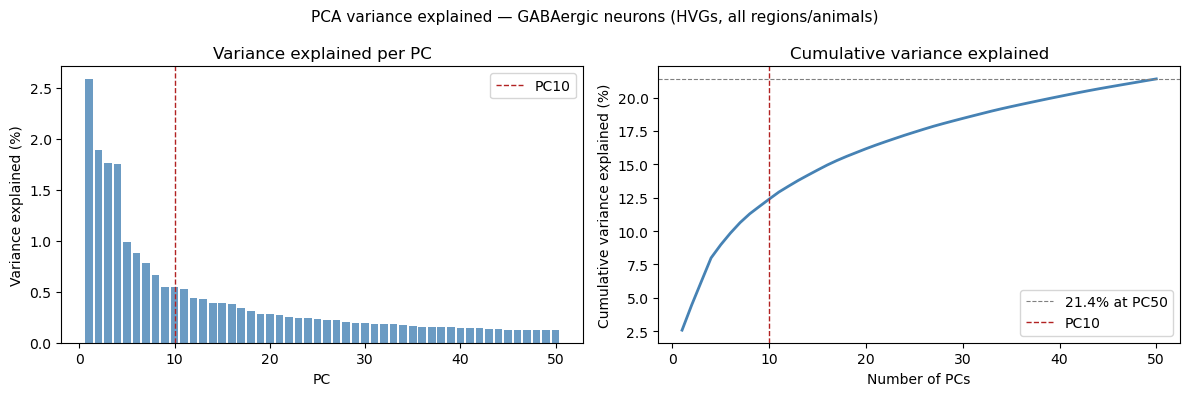

PC1 alone: 2.6%
PC1-10:    12.4%
PC1-50:    21.4%


In [29]:
# Variance explained by each PC
#variance_ratio = np.array([0.026, 0.019, 0.018, 0.018, 0.01, 0.009, 0.008, 0.007, 0.006, 0.005,
                            # load from h5ad instead:
 #                          ])

# Better — load directly
with h5py.File(H5AD, 'r') as f:
    variance_ratio = f['uns']['pca']['variance_ratio'][:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Plot 1: variance per PC ---
axes[0].bar(range(1, 51), variance_ratio[:50] * 100, color='steelblue', alpha=0.8)
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('Variance explained per PC')
axes[0].axvline(10, color='firebrick', lw=1, ls='--', label='PC10')
axes[0].legend()

# --- Plot 2: cumulative variance ---
cumvar = np.cumsum(variance_ratio[:50]) * 100
axes[1].plot(range(1, 51), cumvar, color='steelblue', lw=2)
axes[1].axhline(cumvar[-1], color='grey', lw=0.8, ls='--', label=f'{cumvar[-1]:.1f}% at PC50')
axes[1].axvline(10, color='firebrick', lw=1, ls='--', label='PC10')
axes[1].set_xlabel('Number of PCs')
axes[1].set_ylabel('Cumulative variance explained (%)')
axes[1].set_title('Cumulative variance explained')
axes[1].legend()

plt.suptitle('PCA variance explained — GABAergic neurons (HVGs, all regions/animals)', fontsize=11)
plt.tight_layout()
plt.show()

print(f'PC1 alone: {variance_ratio[0]*100:.1f}%')
print(f'PC1-10:    {variance_ratio[:10].sum()*100:.1f}%')
print(f'PC1-50:    {variance_ratio[:50].sum()*100:.1f}%')

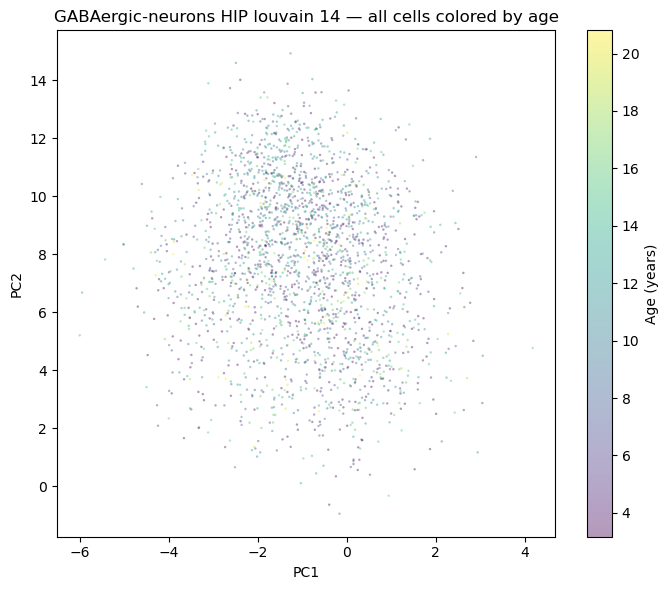

In [35]:
# All cells in this louvain × region
pca_sub  = X_pca[region_mask & (louvain == DEMO_LOUVAIN), :]
ages_sub = ages[region_mask & (louvain == DEMO_LOUVAIN)]

# Change these to plot any two PCs (0-indexed)
PC_X, PC_Y = 0, 1  # 0, 1 is PC1 vs PC2; 1, 2 is PC2 vs PC3

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(pca_sub[:, PC_X], pca_sub[:, PC_Y],
                c=ages_sub, cmap='viridis', s=3, alpha=0.4, linewidths=0, rasterized=True)
plt.colorbar(sc, ax=ax, label='Age (years)')
ax.set_xlabel(f'PC{PC_X + 1}')
ax.set_ylabel(f'PC{PC_Y + 1}')
ax.set_title(f'{CELL_TYPE} {REGION} louvain {DEMO_LOUVAIN} — all cells colored by age')
plt.tight_layout()
plt.show()

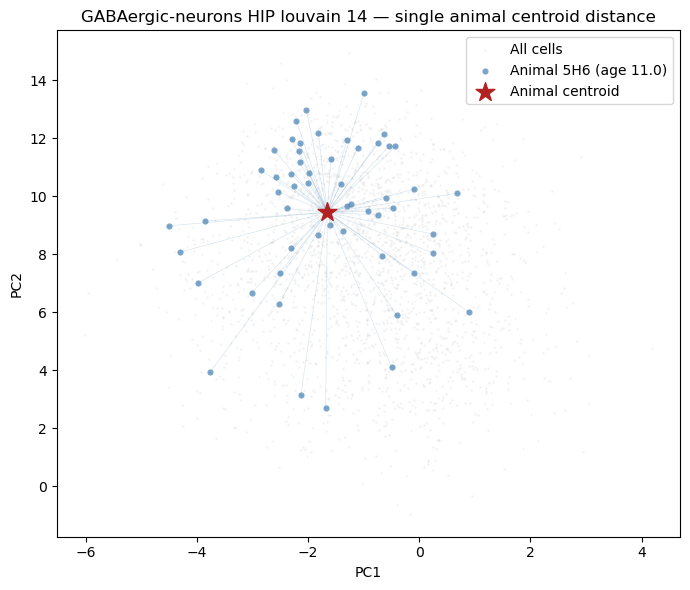

In [36]:
# Pick one animal to highlight
demo_animal = df_within.iloc[len(df_within)//2]['animal_id']  

cell_mask  = region_mask & (louvain == DEMO_LOUVAIN) & (animal_ids == demo_animal)
local_pca  = X_pca[cell_mask]
centroid   = local_pca.mean(axis=0)
age_val    = ages[cell_mask][0]

fig, ax = plt.subplots(figsize=(7, 6))

# All cells in background, greyed out
ax.scatter(pca_2d[:, 0], pca_2d[:, 1],
           c='lightgrey', s=3, alpha=0.3, linewidths=0, rasterized=True, label='All cells')

# This animal's cells
ax.scatter(local_pca[:, 0], local_pca[:, 1],
           c='steelblue', s=20, alpha=0.7, linewidths=0, label=f'Animal {demo_animal} (age {age_val:.1f})')

# This animal's centroid
ax.scatter(centroid[0], centroid[1],
           c='firebrick', s=200, marker='*', zorder=10, label='Animal centroid')

# Lines from centroid to each cell
for cell in local_pca:
    ax.plot([centroid[0], cell[0]], [centroid[1], cell[1]],
            color='steelblue', alpha=0.2, lw=0.5)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'{CELL_TYPE} {REGION} louvain {DEMO_LOUVAIN} — single animal centroid distance')
ax.legend()
plt.tight_layout()
plt.show()

In [27]:
# Boolean mask: cells in our target louvain cluster AND region
mask = region_mask & (louvain == DEMO_LOUVAIN)
# Get integer indices of those cells
idxs = np.where(mask)[0]

rows = []
for animal in np.unique(animal_ids[idxs]):
    # Boolean mask for this animal's cells within the louvain
    am = animal_ids[idxs] == animal
    # Skip animals with too few cells to compute a meaningful centroid
    if am.sum() < 2:
        continue
    # PCA coordinates for this animal's cells only, shape (n_cells, 50)
    local_pca = X_pca[idxs][am]
    # Centroid = mean across cells → shape (50,)
    centroid  = local_pca.mean(axis=0)
    # Euclidean distance from each cell to its own animal's centroid
    dists     = np.sqrt(((local_pca - centroid) ** 2).sum(axis=1))
    rows.append({
        'animal_id': animal,
        'age':       ages[idxs][am][0],   # age is same for all cells from one animal
        'n_cells':   am.sum(),
        'mean_dist': dists.mean(),         # average spread of this animal's cells
        'var_dist':  dists.var(),          # heterogeneity of spread
    })

# One row per animal, sorted by age for plotting
df_within = pd.DataFrame(rows).sort_values('age')
df_within.head()

,animal_id,age,n_cells,mean_dist,var_dist
12,2S6,3.17,159,9.383988,10.086733
29,4S3,3.18,57,9.991722,14.283615
10,2Q0,3.21,50,10.043425,9.795749
28,4Q6,3.22,89,10.900490,19.026114
21,3R7,3.32,57,10.468744,16.462746


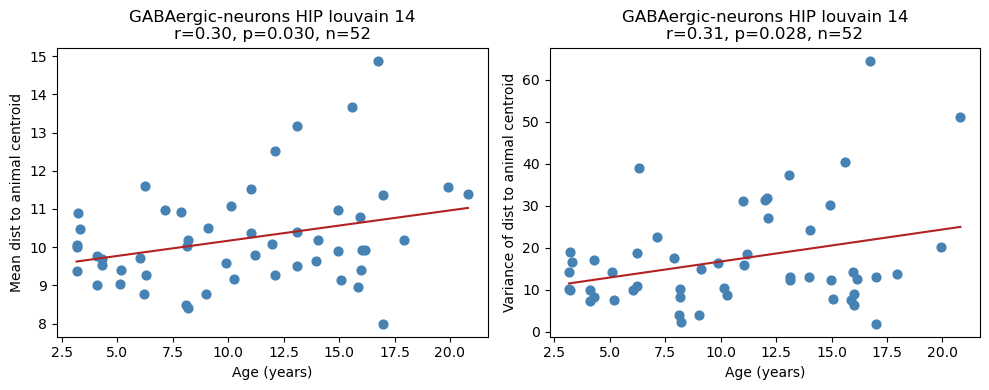

In [28]:
# Pearson correlation + linear regression for mean distance ~ age
slope_m, intercept_m, r_m, p_m, _ = stats.linregress(df_within['age'], df_within['mean_dist'])
# Same for variance ~ age
slope_v, intercept_v, r_v, p_v, _ = stats.linregress(df_within['age'], df_within['var_dist'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loop over both metrics (mean and variance) to avoid repeating plot code
for ax, col, slope, intercept, r, p, ylabel in [
    (axes[0], 'mean_dist', slope_m, intercept_m, r_m, p_m, 'Mean dist to animal centroid'),
    (axes[1], 'var_dist',  slope_v, intercept_v, r_v, p_v, 'Variance of dist to animal centroid'),
]:
    # One dot per animal
    ax.scatter(df_within['age'], df_within[col], color='steelblue', s=40)
    # Regression line
    x_line = np.linspace(df_within['age'].min(), df_within['age'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='firebrick', lw=1.5)
    ax.set_xlabel('Age (years)')
    ax.set_ylabel(ylabel)
    # Title shows r and p from the regression above
    ax.set_title(f'{CELL_TYPE} {REGION} louvain {DEMO_LOUVAIN}\nr={r:.2f}, p={p:.3f}, n={len(df_within)}')

plt.tight_layout()
plt.show()

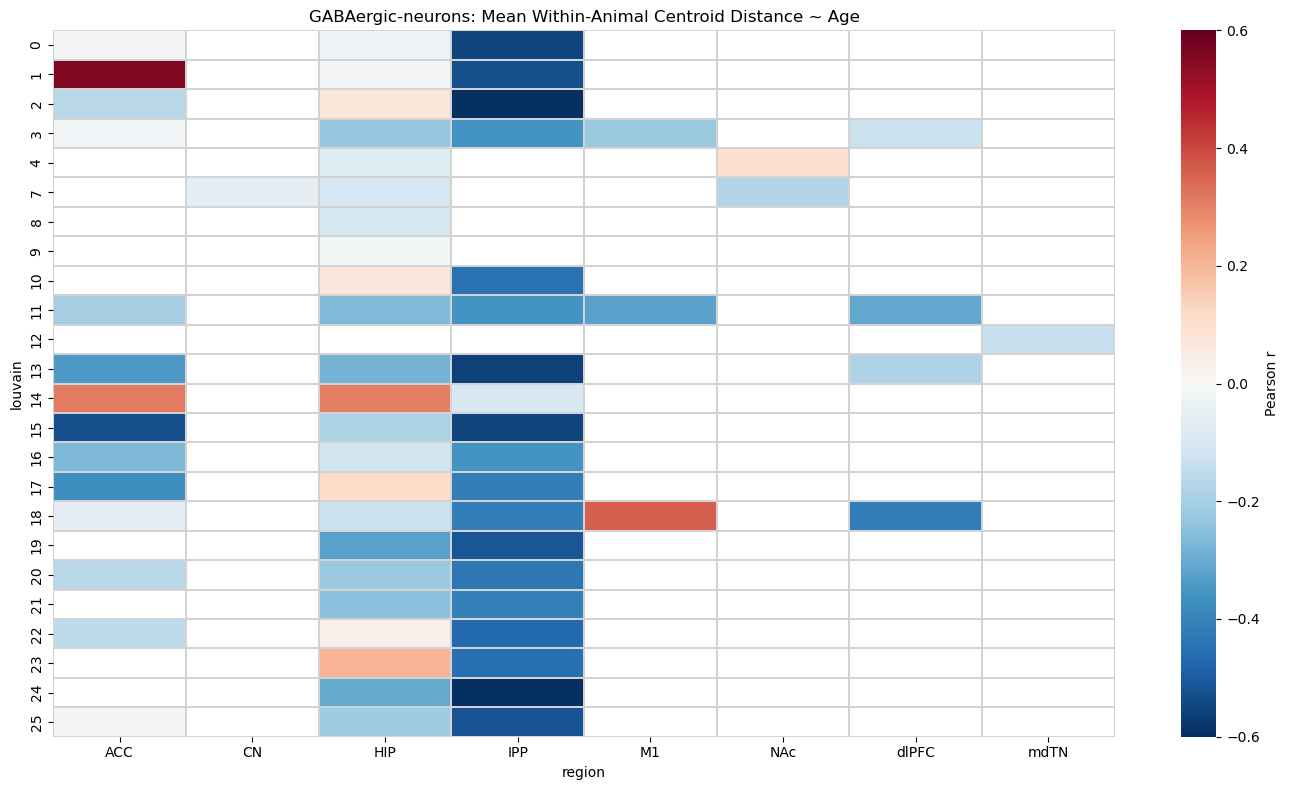

In [9]:
# Heatmap across all Louvains
summary_within = pd.read_csv(os.path.join(OUT_WITHIN, f'{CELL_TYPE}_centroid_summary.csv'))
pivot = summary_within.pivot_table(index='louvain', columns='region', values='r_mean')
pivot.index = pivot.index.astype(str)
pivot = pivot.reindex(sorted(pivot.index, key=lambda x: int(x)))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.3, linecolor='lightgrey', cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title(f'{CELL_TYPE}: Mean Within-Animal Centroid Distance ~ Age')
plt.tight_layout(); plt.show()

### Part 2 — population centroid distances

In [10]:
pca_all      = X_pca[idxs]
pop_centroid = pca_all.mean(axis=0)

rows = []
for animal in np.unique(animal_ids[idxs]):
    am = animal_ids[idxs] == animal
    if am.sum() < 2:
        continue
    local_pca = X_pca[idxs][am]
    dists = np.sqrt(((local_pca - pop_centroid) ** 2).sum(axis=1))
    rows.append({'animal_id': animal, 'age': ages[idxs][am][0],
                 'n_cells': am.sum(), 'mean_dist': dists.mean(), 'var_dist': dists.var()})

df_pop = pd.DataFrame(rows).sort_values('age')
df_pop.head()

,animal_id,age,n_cells,mean_dist,var_dist
12,2S6,3.17,159,9.844395,7.854073
29,4S3,3.18,57,10.217208,14.891003
10,2Q0,3.21,50,10.276093,8.784822
28,4Q6,3.22,89,11.058713,20.328957
21,3R7,3.32,57,10.910542,16.014694


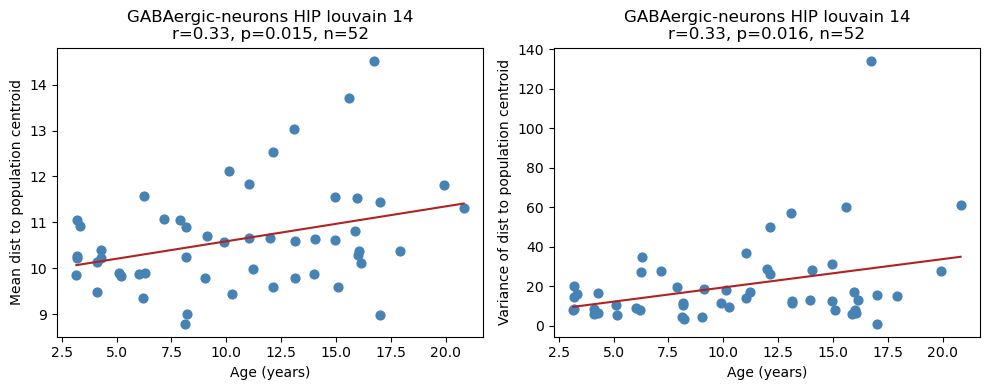

In [12]:
# Regress and plot
slope_m, intercept_m, r_m, p_m, _ = stats.linregress(df_pop['age'], df_pop['mean_dist'])
slope_v, intercept_v, r_v, p_v, _ = stats.linregress(df_pop['age'], df_pop['var_dist'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, slope, intercept, r, p, ylabel in [
    (axes[0], 'mean_dist', slope_m, intercept_m, r_m, p_m, 'Mean dist to population centroid'),
    (axes[1], 'var_dist',  slope_v, intercept_v, r_v, p_v, 'Variance of dist to population centroid'),
]:
    ax.scatter(df_pop['age'], df_pop[col], color='steelblue', s=40)
    x_line = np.linspace(df_pop['age'].min(), df_pop['age'].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color='firebrick', lw=1.5)
    ax.set_xlabel('Age (years)'); ax.set_ylabel(ylabel)
    ax.set_title(f'{CELL_TYPE} {REGION} louvain {DEMO_LOUVAIN}\nr={r:.2f}, p={p:.3f}, n={len(df_pop)}')
plt.tight_layout(); plt.show()

/tmp/ipykernel_1180412/708750724.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap     = cm.get_cmap('viridis')


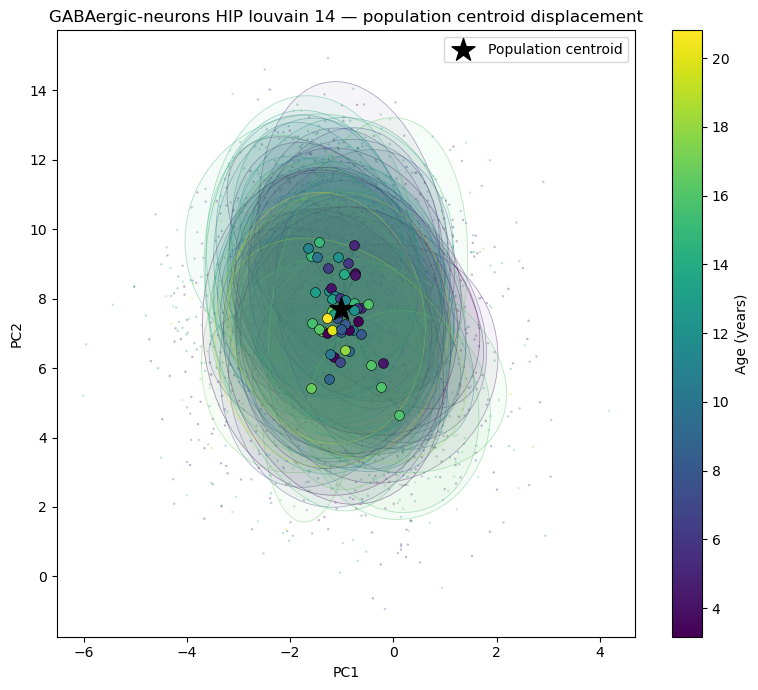

In [13]:
def confidence_ellipse(x, y, ax, n_std=1.5, **kwargs):
    if len(x) < 3: return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1] + 1e-12)
    ellipse = Ellipse((0, 0), width=np.sqrt(1+pearson)*2, height=np.sqrt(1-pearson)*2, **kwargs)
    transf = (transforms.Affine2D().rotate_deg(45)
              .scale(np.sqrt(cov[0,0])*n_std, np.sqrt(cov[1,1])*n_std)
              .translate(np.mean(x), np.mean(y)))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

pca_2d   = X_pca[idxs, :2]
ages_sub = ages[idxs]
aids_sub = animal_ids[idxs]
pop_c2d  = pca_2d.mean(axis=0)
norm     = plt.Normalize(vmin=ages_sub.min(), vmax=ages_sub.max())
cmap     = cm.get_cmap('viridis')

fig, ax = plt.subplots(figsize=(8, 7))
bg = np.random.choice(len(pca_2d), min(3000, len(pca_2d)), replace=False)
ax.scatter(pca_2d[bg, 0], pca_2d[bg, 1],
           c=[cmap(norm(ages_sub[i])) for i in bg], s=3, alpha=0.3, linewidths=0, rasterized=True)
ax.scatter(*pop_c2d, c='black', s=300, marker='*', zorder=10, label='Population centroid')

for animal in np.unique(aids_sub):
    am = aids_sub == animal
    if am.sum() < 2: continue
    apca  = pca_2d[am]
    color = cmap(norm(ages_sub[am][0]))
    ac    = apca.mean(axis=0)
    ax.plot([pop_c2d[0], ac[0]], [pop_c2d[1], ac[1]], color=color, alpha=0.5, lw=0.8)
    ax.scatter(*ac, c=[color], s=50, edgecolors='black', linewidths=0.4, zorder=6)
    if am.sum() >= 3:
        confidence_ellipse(apca[:,0], apca[:,1], ax, n_std=1.5,
                           facecolor=(*color[:3], 0.05), edgecolor=(*color[:3], 0.4),
                           linewidth=0.6, zorder=4)

plt.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), ax=ax, label='Age (years)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'{CELL_TYPE} {REGION} louvain {DEMO_LOUVAIN} — population centroid displacement')
ax.legend(); plt.tight_layout(); plt.show()

In [14]:
# Step 1: build PCA distance matrices
# !python {SCRIPTS}/compute_pca_distance_matrix.py \
#     --h5ad {H5AD} --region {REGION} \
#     --output-dir {OUT_LOCHNESS_DIST} --all-louvains

# Step 2: run lochNESS scoring
# for npy in glob.glob(f'{OUT_LOCHNESS_DIST}/*_{REGION}_*_pca_distance_matrix.npy'):
#     csv = npy.replace('_distance_matrix.npy', '_cell_metadata.csv')
#     !python /scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py \
#         --dist-matrix {npy} --metadata {csv} --output-dir {OUT_LOCHNESS_SCR}

# Step 3: summarize
# !python /scratch/easmit31/dissimilarity_analysis/summarize_lochness_results.py \
#     --input-dir {OUT_LOCHNESS_SCR} --output-dir {OUT_LOCHNESS_SCR}

npy_files = glob.glob(os.path.join(OUT_LOCHNESS_DIST, f'*_{REGION}_*_pca_distance_matrix.npy'))
print(f'Distance matrix files: {len(npy_files)}')

Distance matrix files: 25


In [15]:
p1 = summary_within[summary_within['region'] == REGION][['louvain','r_mean','p_mean']].copy()
p1.columns = ['louvain','r_within','p_within']
p1['louvain'] = p1['louvain'].astype(str)

p2 = summary_pop[['louvain','r_mean_dist','p_mean_dist']].copy()
p2.columns = ['louvain','r_pop','p_pop']
p2['louvain'] = p2['louvain'].astype(str)

combined = pd.merge(p1, p2, on='louvain', how='outer').sort_values('louvain', key=lambda x: x.astype(int))
combined['sig_within'] = combined['p_within'] < 0.05
combined['sig_pop']    = combined['p_pop']    < 0.05

print(f"Both significant: {(combined['sig_within'] & combined['sig_pop']).sum()}")
combined[combined['sig_within'] & combined['sig_pop']].round(3)

NameError: name 'summary_pop' is not defined

In [16]:
colors = combined.apply(
    lambda r: 'firebrick' if (r['sig_within'] and r['sig_pop'])
              else 'steelblue' if (r['sig_within'] or r['sig_pop'])
              else 'lightgrey', axis=1)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(combined['r_within'], combined['r_pop'], c=colors, s=60, edgecolors='black', linewidths=0.5)
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(0, color='black', lw=0.5, ls='--')
for _, row in combined[combined['sig_within'] | combined['sig_pop']].iterrows():
    ax.annotate(str(row['louvain']), (row['r_within'], row['r_pop']), fontsize=8)
ax.set_xlabel('Part 1 r (within-animal)'); ax.set_ylabel('Part 2 r (population)')
ax.set_title(f'{CELL_TYPE} {REGION}')
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor='firebrick',markersize=8,label='Both sig'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='steelblue',markersize=8,label='One sig'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor='lightgrey',markersize=8,label='Neither'),
])
plt.tight_layout(); plt.show()

NameError: name 'combined' is not defined

In [1]:
import os
import sys

# Paths
SCRIPTS_DIR  = '/scratch/easmit31/factor_analysis/scripts'
H5AD         = '/data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad'
REGION       = 'HIP'
CELL_TYPE    = 'GABAergic'
OUTPUT_BASE  = '/scratch/easmit31/factor_analysis'

# Output subdirectories
OUT_WITHIN_ANIMAL  = os.path.join(OUTPUT_BASE, 'pc_centroid_outputs_min100')
OUT_POP_CENTROID   = os.path.join(OUTPUT_BASE, 'population_centroid_outputs')
OUT_LOCHNESS       = '/scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/GABAergic-neurons'
OUT_LOCHNESS_SCORES = '/scratch/easmit31/dissimilarity_analysis/lochness_pca/GABAergic-neurons'

for d in [OUT_WITHIN_ANIMAL, OUT_POP_CENTROID, OUT_LOCHNESS, OUT_LOCHNESS_SCORES]:
    os.makedirs(d, exist_ok=True)

print('Paths OK')

Paths OK


---

## Part 1: Within-animal centroid distance

### Concept

For each louvain cluster × region, we compute each animal's **own centroid** in PCA space (mean of that animal's cells). We then measure each cell's Euclidean distance to its own animal's centroid.

Per animal, we aggregate:
- **Mean distance**: how spread out are the animal's cells around their own center?
- **Variance of distances**: is within-animal heterogeneity increasing?

Both are regressed against age (Pearson r, p-value).

**Interpretation**: Increasing mean/variance with age = cells drifting further from their own animal's transcriptional consensus. This captures *internal* transcriptional spread, not displacement relative to other animals.

### Key distinction
The centroid here is **per-animal**, not population-level. An animal where all cells are uniformly shifted away from the population mean would score *low* on this metric (cells are tightly packed around their own center) but *high* on Part 2 (population centroid distance).

### Script
`pca_centroid_distance_by_louvain.py` — loops all louvain clusters in the given region, saves:
- Scatter plots (mean + variance vs age) per louvain → `factor_analysis/`
- Summary CSV per cell type → `pc_centroid_outputs_min100/{cell_type}_centroid_summary.csv`
- Heatmaps (Pearson r across louvain × region) → `pc_centroid_outputs_min100/`

### Status
✅ **Complete** — all cell types × all regions already run. Results in `pc_centroid_outputs_min100/`.

In [2]:
# View existing summary CSV for GABAergic
import pandas as pd

summary_within = pd.read_csv(os.path.join(OUT_WITHIN_ANIMAL, 'GABAergic-neurons_centroid_summary.csv'))
hip = summary_within[summary_within['region'] == REGION].sort_values('louvain')
print(f'GABAergic HIP — {len(hip)} louvains')
hip[['louvain', 'n_cells', 'n_animals', 'r_mean', 'p_mean', 'r_var', 'p_var']].head(10)

GABAergic HIP — 23 louvains


,louvain,n_cells,n_animals,r_mean,p_mean,r_var,p_var
44,0,537,52,-0.0248,0.8614,0.0972,0.4928
45,1,2233,52,-0.0095,0.9465,-0.1364,0.3350
55,2,523,47,0.0706,0.6373,-0.0839,0.5750
62,3,249,40,-0.2297,0.1540,-0.1144,0.4821
63,4,499,50,-0.0841,0.5614,-0.2369,0.0976
64,7,211,19,-0.1047,0.6697,0.0477,0.8461
65,8,983,51,-0.1076,0.4523,0.0567,0.6928
66,9,1867,52,-0.0160,0.9105,0.0789,0.5784
46,10,595,51,0.0663,0.6440,0.0498,0.7286
47,11,458,51,-0.2645,0.0607,-0.2599,0.0655


In [3]:
# To rerun Part 1 for GABAergic HIP (edit parameters at top of script first)
# !python {SCRIPTS_DIR}/pca_centroid_distance_by_louvain.py

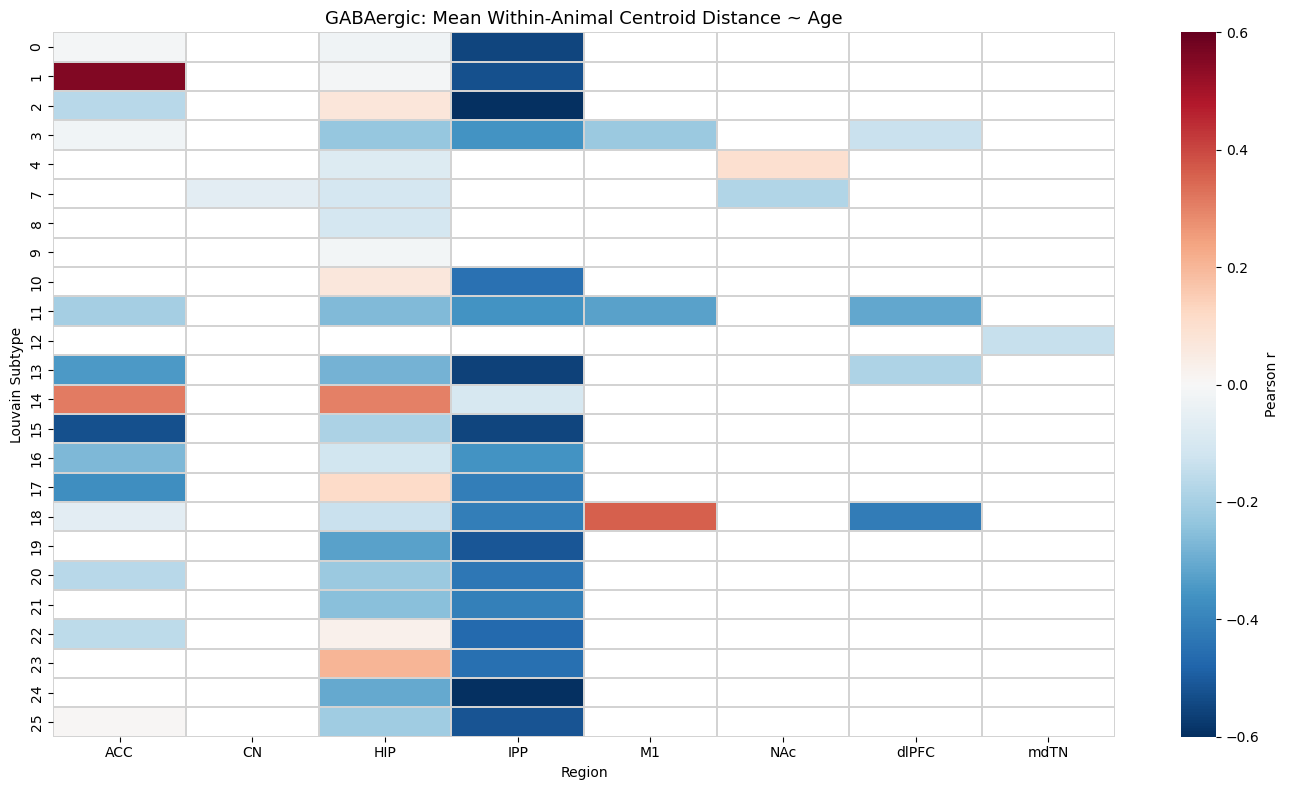

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

summary_within = pd.read_csv(os.path.join(OUT_WITHIN_ANIMAL, 'GABAergic-neurons_centroid_summary.csv'))
hip = summary_within[summary_within['region'] == REGION].copy()

pivot = hip.pivot(index='louvain', columns='region', values='r_mean')

# or for all regions at once:
pivot_all = summary_within.pivot_table(index='louvain', columns='region', values='r_mean')
pivot_all.index = pivot_all.index.astype(str)
pivot_all = pivot_all.reindex(sorted(pivot_all.index, key=lambda x: int(x)))

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_all, cmap='RdBu_r', center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.3, linecolor='lightgrey',
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title(f'{CELL_TYPE}: Mean Within-Animal Centroid Distance ~ Age', fontsize=13)
ax.set_xlabel('Region')
ax.set_ylabel('Louvain Subtype')
plt.tight_layout()
plt.show()

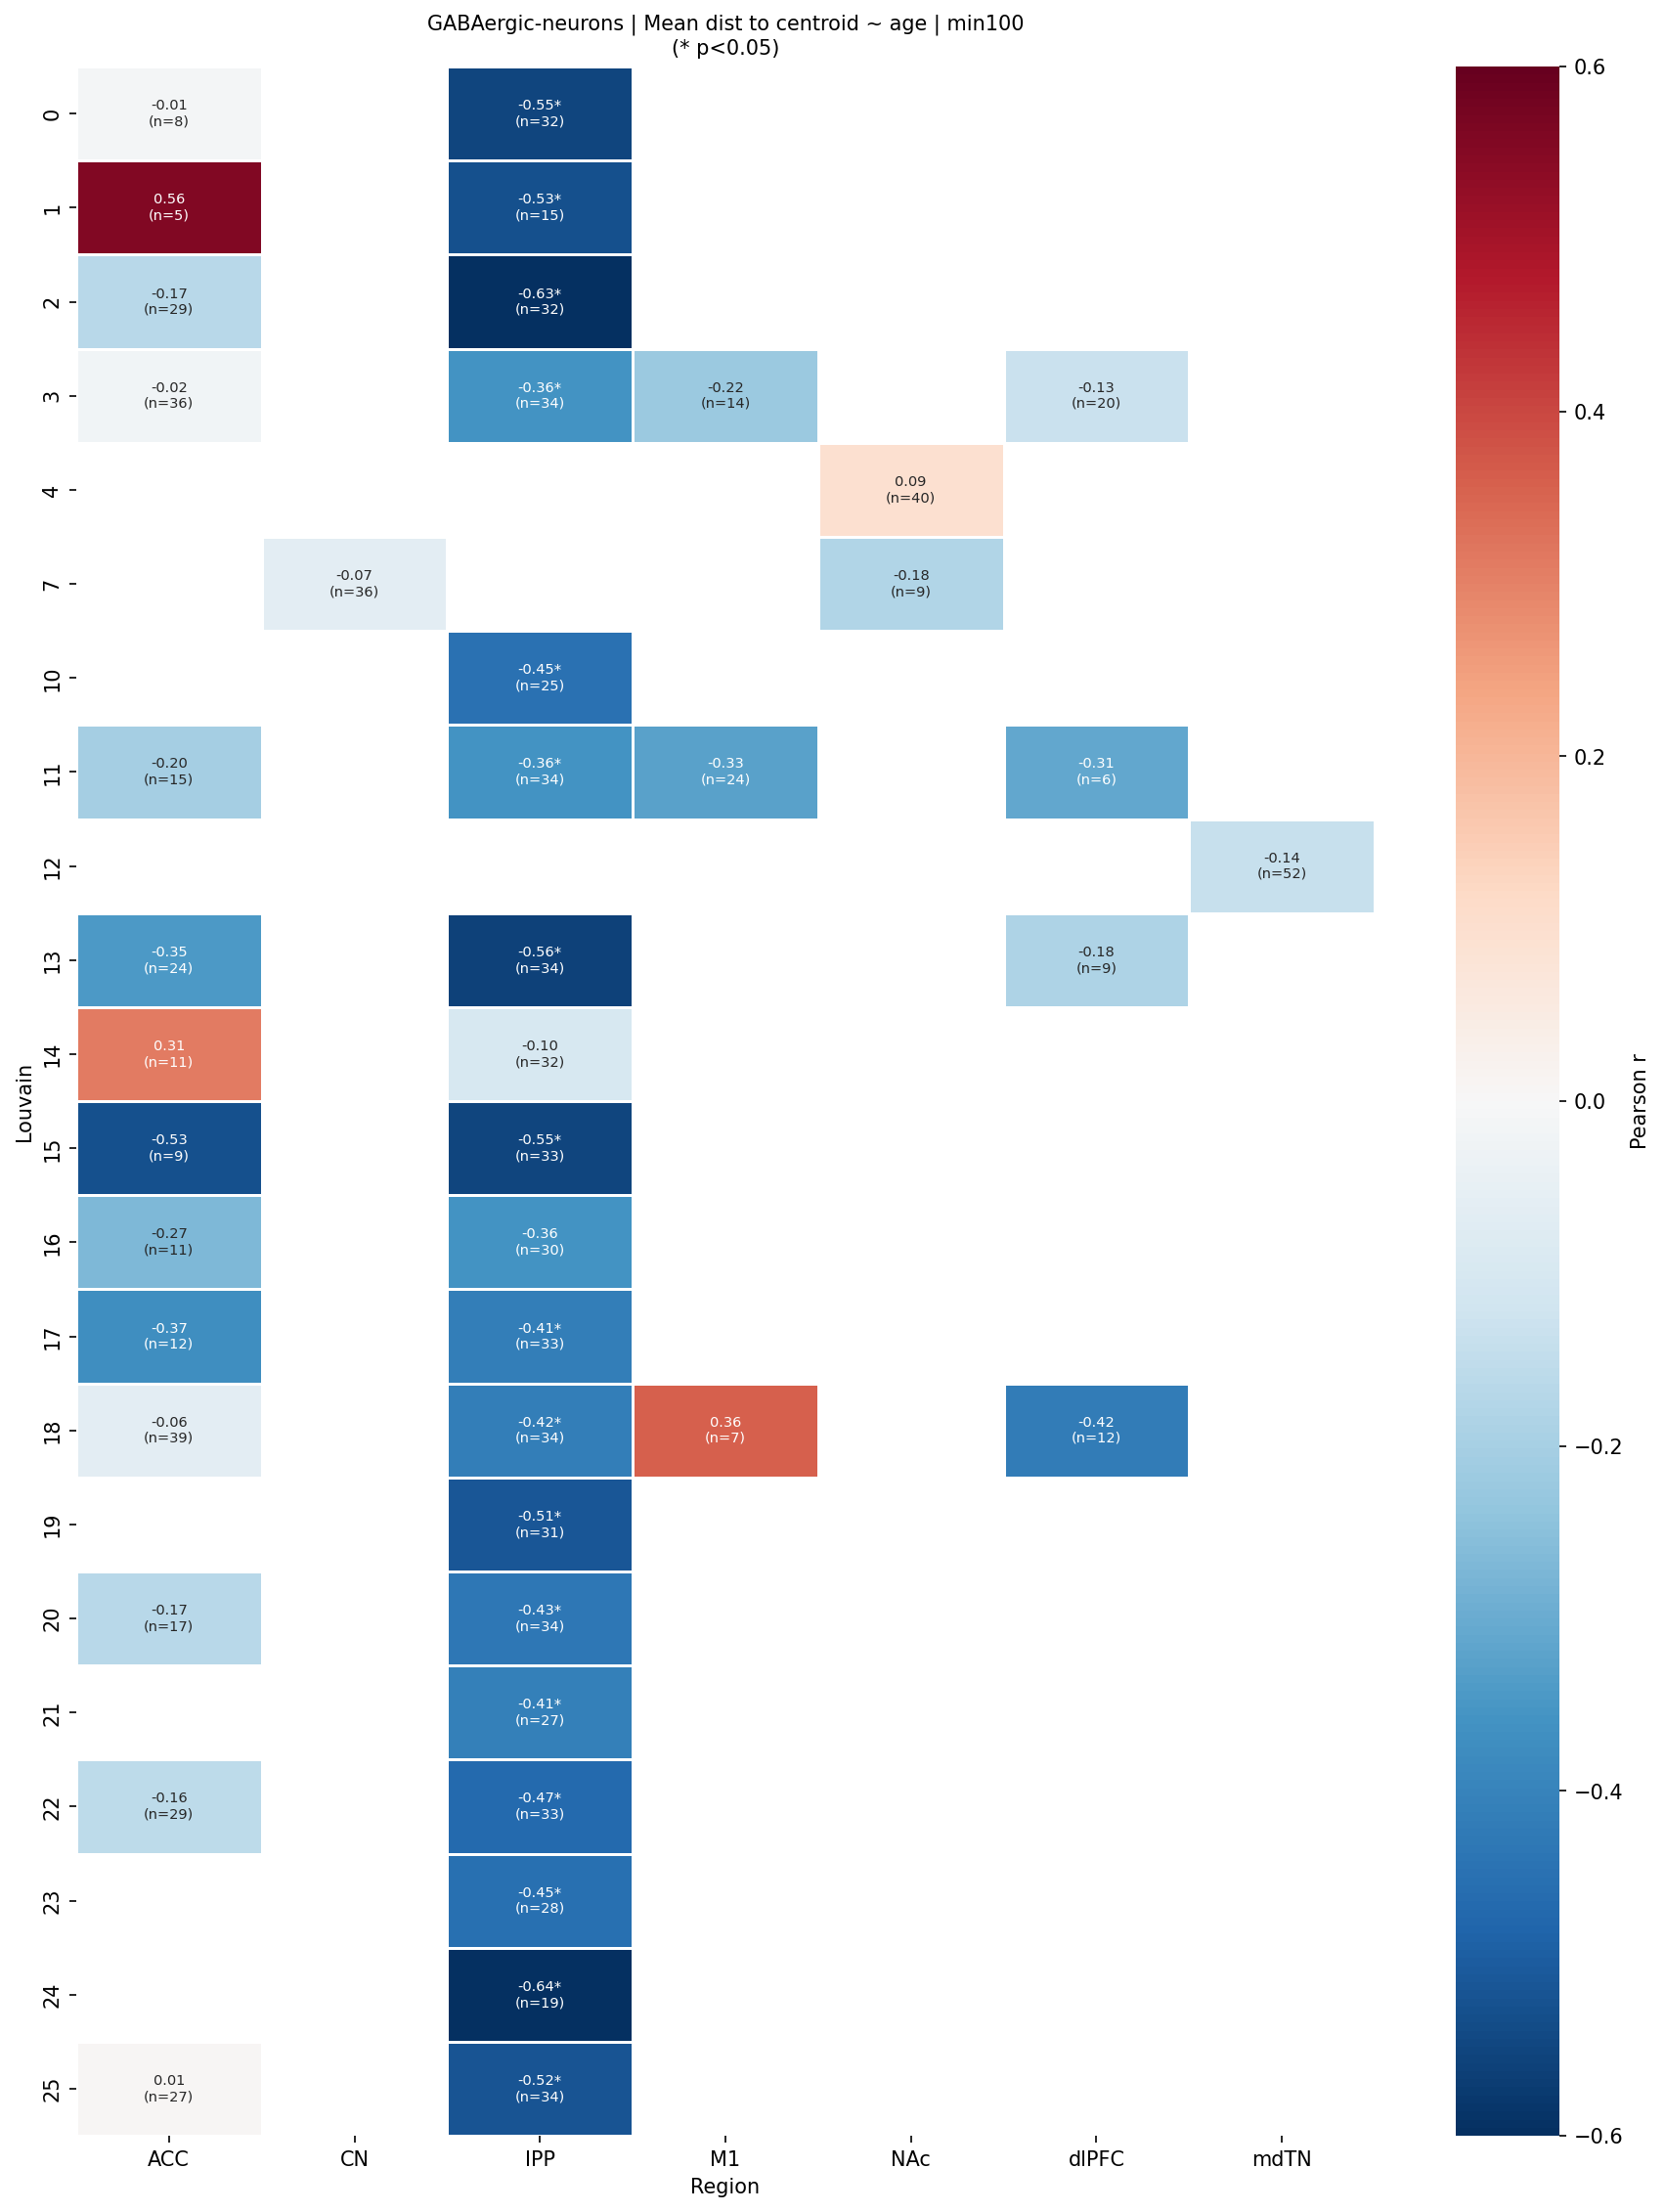

In [3]:
# View the mean centroid distance heatmap
from IPython.display import Image
Image(os.path.join(OUT_WITHIN_ANIMAL, 'GABAergic-neurons_heatmap_mean_min100.png'))

---

## Part 2: Population centroid distance

### Concept

For each louvain cluster × region, we compute a single **population centroid** — the mean PCA coordinate across *all* cells from *all* animals combined. We then measure each animal's cells' distances to that fixed population centroid.

Per animal, we aggregate:
- **Mean distance**: is this animal's cells collectively displaced from the group consensus?
- **Variance of distances**: are this animal's cells spread out around the population center?

Both are regressed against age.

**Interpretation**: Increasing mean distance with age = older animals' cells are transcriptionally atypical relative to the group. An animal can show a coherent shift (far from population centroid, low variance) or diffuse heterogeneity (close on average, high variance).

### Script
`pca_population_centroid_distance.py` — saves:
- Scatter plots per louvain → `population_centroid_outputs/`
- Summary CSV → `population_centroid_outputs/{cell_type}_{region}_population_centroid_summary.csv`

### Status
✅ **Complete for GABAergic HIP**. Other cell types × regions not yet run.

In [5]:
# Run Part 2 for GABAergic HIP
# Parameters are set at the top of the script — verify before running
!python {SCRIPTS_DIR}/pca_population_centroid_distance.py

Loading /data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad...
Found 26 louvain clusters in HIP
  Saved louvain 0 (n_cells=537, n_animals=52, mean_r=0.026 p=0.857, var_r=0.155 p=0.272)
  Saved louvain 1 (n_cells=2233, n_animals=52, mean_r=0.211 p=0.133, var_r=-0.155 p=0.274)
  Saved louvain 10 (n_cells=595, n_animals=51, mean_r=0.073 p=0.611, var_r=0.160 p=0.262)
  Saved louvain 11 (n_cells=458, n_animals=51, mean_r=-0.088 p=0.540, var_r=-0.102 p=0.475)
  Skipping louvain 12: only 72 cells
  Saved louvain 13 (n_cells=309, n_animals=41, mean_r=-0.171 p=0.285, var_r=-0.184 p=0.250)
  Saved louvain 14 (n_cells=2174, n_animals=52, mean_r=0.334 p=0.015, var_r=0.333 p=0.016)
  Saved louvain 15 (n_cells=722, n_animals=52, mean_r=-0.008 p=0.955, var_r=-0.151 p=0.286)
  Saved louvain 16 (n_cells=257, n_animals=44, mean_r=0.152 p=0.325, var_r=0.058 p=0.707)
  Saved louvain 17 (n_cells=1052, n_animals=51, mean_r=0.193 p=0.176, var_r=-0.026 p=0.856)
  Saved louvain 18 (n_cells=1454, n_animal

In [6]:
# View summary results
summary_pop = pd.read_csv(os.path.join(OUT_POP_CENTROID, f'{CELL_TYPE}_{REGION}_population_centroid_summary.csv'))
print(f'{len(summary_pop)} louvains')
summary_pop.sort_values('p_mean_dist').head(10)

23 louvains


,louvain,n_cells,n_animals,r_mean_dist,p_mean_dist,r_var_dist,p_var_dist
15,23,1007,52,0.339912,0.013684,0.314718,0.023064
5,14,2174,52,0.334360,0.015407,0.333123,0.015815
13,21,168,28,-0.385100,0.043005,-0.297764,0.123822
1,1,2233,52,0.211276,0.132703,-0.154615,0.273762
14,22,359,41,0.238508,0.133165,0.271785,0.085618
11,2,523,47,0.211714,0.153117,-0.113176,0.448786
8,17,1052,51,0.192671,0.175556,-0.026133,0.855557
12,20,800,52,-0.164766,0.243104,-0.183402,0.193102
4,13,309,41,-0.170934,0.285272,-0.183662,0.250370
22,9,1867,52,0.142756,0.312692,0.075200,0.596221


In [7]:
# Identify significant louvains (p < 0.05)
sig_mean = summary_pop[summary_pop['p_mean_dist'] < 0.05].sort_values('r_mean_dist')
sig_var  = summary_pop[summary_pop['p_var_dist']  < 0.05].sort_values('r_var_dist')

print(f'Significant for mean distance ~ age: {len(sig_mean)} louvains')
print(sig_mean[['louvain', 'n_cells', 'n_animals', 'r_mean_dist', 'p_mean_dist']])
print(f'\nSignificant for variance ~ age: {len(sig_var)} louvains')
print(sig_var[['louvain', 'n_cells', 'n_animals', 'r_var_dist', 'p_var_dist']])

Significant for mean distance ~ age: 3 louvains
    louvain  n_cells  n_animals  r_mean_dist  p_mean_dist
13       21      168         28    -0.385100     0.043005
5        14     2174         52     0.334360     0.015407
15       23     1007         52     0.339912     0.013684

Significant for variance ~ age: 4 louvains
    louvain  n_cells  n_animals  r_var_dist  p_var_dist
10       19      175         32   -0.396868    0.024515
9        18     1454         51    0.302895    0.030733
15       23     1007         52    0.314718    0.023064
5        14     2174         52    0.333123    0.015815


In [8]:
# PC1/PC2 visualization — panel of top significant louvains
!python {SCRIPTS_DIR}/plot_pca_population_centroid_2d.py \
    --h5ad {H5AD} \
    --region {REGION} \
    --cell-type {CELL_TYPE} \
    --summary-csv {OUT_POP_CENTROID}/{CELL_TYPE}_{REGION}_population_centroid_summary.csv \
    --top-n 6 \
    --output-dir {OUT_POP_CENTROID}

Loading /data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad...
  17592 cells in HIP (age >= 1.0)
Saved panel: /scratch/easmit31/factor_analysis/population_centroid_outputs/GABAergic_HIP_top3_pc12_popcentroid_panel.png
Done.


In [9]:
Image(os.path.join(OUT_POP_CENTROID, f'{CELL_TYPE}_{REGION}_top6_pc12_popcentroid_panel.png'))

FileNotFoundError: No such file or directory: '/scratch/easmit31/factor_analysis/population_centroid_outputs/GABAergic_HIP_top6_pc12_popcentroid_panel.png'

FileNotFoundError: No such file or directory: '/scratch/easmit31/factor_analysis/population_centroid_outputs/GABAergic_HIP_top6_pc12_popcentroid_panel.png'

<IPython.core.display.Image object>

---

## Part 3: lochNESS (age-based neighbor enrichment)

### Concept

lochNESS asks whether each cell's k nearest neighbors in PCA space are enriched for cells from old animals or young animals, beyond what would be expected by chance.

For each cell:
1. Find k=10 nearest neighbors in PCA space
2. Count how many are from "old" animals (age ≥ 10) vs "young" (age < 10)
3. Compute enrichment score relative to the overall proportion of old/young cells
4. Assess significance via permutation test (shuffle age labels, 100 permutations)

**Interpretation**: High positive lochNESS = cell is surrounded by other old-animal cells = age is a strong organizer of transcriptional state. Neutral = cells mix freely across ages in PCA space.

### Pipeline

**Step 3a** — Build PCA distance matrices (new, replaces raw-expression matrices):
```
compute_pca_distance_matrix.py → louvain{N}_{region}_minage1.0_pca_distance_matrix.npy
                                  louvain{N}_{region}_minage1.0_pca_cell_metadata.csv
```

**Step 3b** — Run lochNESS scoring on those matrices:
```
compute_lochness_scores_no_animal_filter.py → per-cell lochNESS scores + significance
```

**Step 3c** — Summarize across louvains:
```
summarize_lochness_results.py → summary CSV + heatmap
```

### Why PCA distance matrices?
The original pipeline computed pairwise distances in raw gene expression space (~20,000 genes). Using PCA space (50 dimensions) is faster, less memory intensive, and consistent with the centroid distance analyses above.

### Why no animal filter?
Same-animal cells are *allowed* in the k nearest neighbors. Excluding them artificially inflates distances and biases enrichment scoring — we want to capture natural neighbor structure.

### Status
✅ **Complete for GABAergic HIP and dlPFC** (using old raw-expression matrices).  
🔲 **Not yet run** with new PCA distance matrices for any cell type.

In [10]:
# Step 3a: Build PCA distance matrices for GABAergic HIP (all louvains)
!python {SCRIPTS_DIR}/compute_pca_distance_matrix.py \
    --h5ad {H5AD} \
    --region {REGION} \
    --output-dir {OUT_LOCHNESS} \
    --all-louvains \
    --min-age 1.0 \
    --n-pcs 50

Loading /data/CEM/smacklab/U01/Res1_GABAergic-neurons_subset.h5ad...
Loaded 544142 cells, X_pca shape: (544142, 50)
Found 26 louvain clusters in HIP
  louvain 0 × HIP: 537 cells — computing distance matrix...
    Saved: /scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/GABAergic-neurons/louvain0_HIP_minage1.0_pca_distance_matrix.npy  (537×537, 1.2 MB)
  louvain 1 × HIP: 2233 cells — computing distance matrix...
    Saved: /scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/GABAergic-neurons/louvain1_HIP_minage1.0_pca_distance_matrix.npy  (2233×2233, 19.9 MB)
  louvain 10 × HIP: 595 cells — computing distance matrix...
    Saved: /scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/GABAergic-neurons/louvain10_HIP_minage1.0_pca_distance_matrix.npy  (595×595, 1.4 MB)
  louvain 11 × HIP: 458 cells — computing distance matrix...
    Saved: /scratch/easmit31/dissimilarity_analysis/pca_distance_matrices/GABAergic-neurons/louvain11_HIP_minage1.0_pca_distance_m

In [11]:
# Verify output files
import glob
npy_files = sorted(glob.glob(os.path.join(OUT_LOCHNESS, f'*_{REGION}_*_pca_distance_matrix.npy')))
print(f'Found {len(npy_files)} distance matrix files')
for f in npy_files[:5]:
    print(' ', os.path.basename(f))

Found 25 distance matrix files
  louvain0_HIP_minage1.0_pca_distance_matrix.npy
  louvain10_HIP_minage1.0_pca_distance_matrix.npy
  louvain11_HIP_minage1.0_pca_distance_matrix.npy
  louvain12_HIP_minage1.0_pca_distance_matrix.npy
  louvain13_HIP_minage1.0_pca_distance_matrix.npy


In [12]:
# Step 3b: Run lochNESS on each distance matrix
# Note: this can be slow for large louvains — consider submitting as SLURM array for full sweeps
import subprocess

lochness_script = '/scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py'
os.makedirs(OUT_LOCHNESS_SCORES, exist_ok=True)

for npy_path in npy_files:
    csv_path = npy_path.replace('_distance_matrix.npy', '_cell_metadata.csv')
    if not os.path.exists(csv_path):
        print(f'Missing metadata: {csv_path}')
        continue
    print(f'Running lochNESS on {os.path.basename(npy_path)}...')
    result = subprocess.run(
        ['python', lochness_script,
         '--dist-matrix', npy_path,
         '--metadata', csv_path,
         '--output-dir', OUT_LOCHNESS_SCORES],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'  ERROR: {result.stderr[-300:]}')
    else:
        print(f'  Done')

Running lochNESS on louvain0_HIP_minage1.0_pca_distance_matrix.npy...
  ERROR: python: can't open file '/scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py': [Errno 2] No such file or directory

Running lochNESS on louvain10_HIP_minage1.0_pca_distance_matrix.npy...
  ERROR: python: can't open file '/scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py': [Errno 2] No such file or directory

Running lochNESS on louvain11_HIP_minage1.0_pca_distance_matrix.npy...
  ERROR: python: can't open file '/scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py': [Errno 2] No such file or directory

Running lochNESS on louvain12_HIP_minage1.0_pca_distance_matrix.npy...
  ERROR: python: can't open file '/scratch/easmit31/dissimilarity_analysis/compute_lochness_scores_no_animal_filter.py': [Errno 2] No such file or directory

Running lochNESS on louvain13_HIP_minage1.0_pca_distance_matrix.npy...
  ERROR: pytho

In [13]:
# Step 3c: Summarize lochNESS results across louvains
!python /scratch/easmit31/dissimilarity_analysis/summarize_lochness_results.py \
    --input-dir {OUT_LOCHNESS_SCORES} \
    --output-dir {OUT_LOCHNESS_SCORES} \
    --region {REGION} \
    --cell-type {CELL_TYPE}

python: can't open file '/scratch/easmit31/dissimilarity_analysis/summarize_lochness_results.py': [Errno 2] No such file or directory


In [14]:
# View lochNESS summary
lochness_summary_path = os.path.join(OUT_LOCHNESS_SCORES, f'lochness_summary_{REGION}.csv')
if os.path.exists(lochness_summary_path):
    lochness_df = pd.read_csv(lochness_summary_path)
    print(lochness_df)
else:
    print(f'Not found: {lochness_summary_path}')

Not found: /scratch/easmit31/dissimilarity_analysis/lochness_pca/GABAergic-neurons/lochness_summary_HIP.csv


---

## Comparing all three metrics

The three analyses ask related but distinct questions. A louvain showing significant effects across all three would be a strong candidate for biological follow-up.

In [15]:
import numpy as np

# Within-animal (Part 1)
p1 = summary_within[summary_within['region'] == REGION][['louvain', 'r_mean', 'p_mean']].copy()
p1.columns = ['louvain', 'r_within', 'p_within']

# Population centroid (Part 2)
p2 = summary_pop[['louvain', 'r_mean_dist', 'p_mean_dist']].copy()
p2.columns = ['louvain', 'r_pop', 'p_pop']
p2['louvain'] = p2['louvain'].astype(str)
p1['louvain']  = p1['louvain'].astype(str)

combined = pd.merge(p1, p2, on='louvain', how='outer')
combined['sig_within'] = combined['p_within'] < 0.05
combined['sig_pop']    = combined['p_pop']    < 0.05

print('Louvains significant in both Part 1 and Part 2:')
both_sig = combined[combined['sig_within'] & combined['sig_pop']]
print(both_sig[['louvain', 'r_within', 'p_within', 'r_pop', 'p_pop']])

print('\nAll results:')
combined.sort_values('louvain').round(3)

Louvains significant in both Part 1 and Part 2:
Empty DataFrame
Columns: [louvain, r_within, p_within, r_pop, p_pop]
Index: []

All results:


,louvain,r_within,p_within,r_pop,p_pop,sig_within,sig_pop
0,0,NaN,NaN,0.026,0.857,False,False
1,1,NaN,NaN,0.211,0.133,False,False
2,10,NaN,NaN,0.073,0.611,False,False
3,11,NaN,NaN,-0.088,0.540,False,False
4,13,NaN,NaN,-0.171,0.285,False,False
5,14,NaN,NaN,0.334,0.015,False,True
6,15,NaN,NaN,-0.008,0.955,False,False
7,16,NaN,NaN,0.152,0.325,False,False
8,17,NaN,NaN,0.193,0.176,False,False
9,18,NaN,NaN,0.012,0.931,False,False


---

## Notes & known issues

- **n_cells confound (Part 1)**: Animals with fewer cells show artificially higher within-animal centroid distances (r = -0.15 to -0.43 in ACC). Whether this reflects sampling noise or real biology (cell loss → scattered survivors) is unresolved. Consider partial correlation controlling for n_cells per animal.
- **PCA space**: All analyses use the global PCA embedding computed during preprocessing across all cells. The first PCs capture broad cell state variation. Recomputing PCA within each louvain cluster would give a space more sensitive to within-subtype variation but would not be directly comparable across louvains.
- **lochNESS age threshold**: Currently set to 10 years (old = age ≥ 10). This is a hard dichotomization — consider sensitivity analysis with different thresholds.
- **Animal 8H2**: Excluded from all ACC analyses as a technical outlier (severely depleted cell counts).